In [ ]:
!pip install google-genai scikit-learn pandas numpy -q
import pandas as pd
import numpy as np

In [ ]:
#S1: Link the GitHub repo in the notebook.
#S2: Create a sub-folder named "data" in the src dir and upload the SAML-D.csv file in it.

In [ ]:
from google.colab import userdata
import os
os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")

In [ ]:
from src.data_loader import load_dataset, clean_dataset
df_raw = load_dataset()
df = clean_dataset(df_raw)
df.head()

Cleaning report: removed 0 duplicate rows, 0 missing values in required columns, final shape (9504852, 12)


,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,Uk Pounds,Uk Pounds,Uk,Uk,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,Uk Pounds,Dirham,Uk,Uae,Cross-Border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,Uk Pounds,Uk Pounds,Uk,Uk,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,Uk Pounds,Uk Pounds,Uk,Uk,Ach,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,Uk Pounds,Uk Pounds,Uk,Uk,Cash Deposit,0,Normal_Cash_Deposits


(9504852, 12)
Is_laundering
0    0.998961
1    0.001039
Name: proportion, dtype: float64


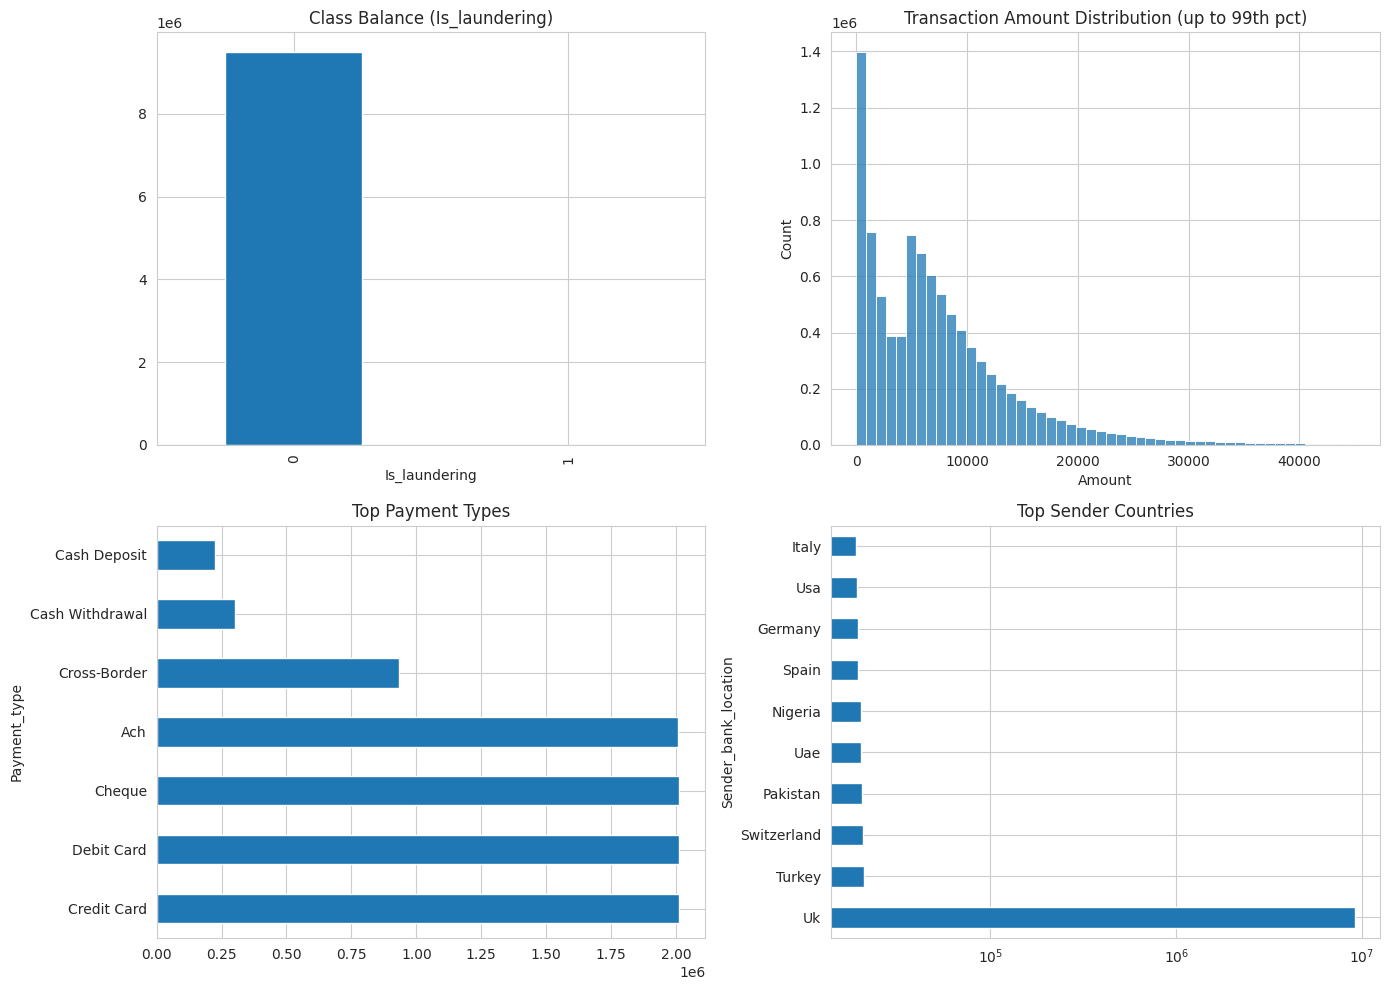

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print(df.shape)
print(df["Is_laundering"].value_counts(normalize=True))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df["Is_laundering"].value_counts().plot(kind="bar", ax=axes[0, 0], title="Class Balance (Is_laundering)")

cap = df["Amount"].quantile(0.99)
sns.histplot(df[df["Amount"] <= cap]["Amount"], bins=50, ax=axes[0, 1])
axes[0, 1].set_title(f"Transaction Amount Distribution (up to 99th pct)")

df["Payment_type"].value_counts().head(10).plot(kind="barh", ax=axes[1, 0], title="Top Payment Types")

df["Sender_bank_location"].value_counts().head(10).plot(kind="barh", ax=axes[1, 1], title="Top Sender Countries", logx=True)

plt.tight_layout()
plt.show()

In [ ]:
print(df["Laundering_type"].value_counts())

Laundering_type
Normal_Small_Fan_Out      3477717
Normal_Fan_Out            2302220
Normal_Fan_In             2104285
Normal_Group               528351
Normal_Cash_Withdrawal     305031
Normal_Cash_Deposits       223801
Normal_Periodical          210526
Normal_Plus_Mutual         155041
Normal_Mutual              125335
Normal_Foward               42031
Normal_single_large         20641
Structuring                  1870
Cash_Withdrawal              1334
Deposit-Send                  945
Smurfing                      932
Layered_Fan_In                656
Layered_Fan_Out               529
Stacked Bipartite             506
Behavioural_Change_1          394
Bipartite                     383
Cycle                         382
Fan_In                        364
Gather-Scatter                354
Behavioural_Change_2          345
Scatter-Gather                338
Single_large                  250
Fan_Out                       237
Over-Invoicing                 54
Name: count, dtype: int64


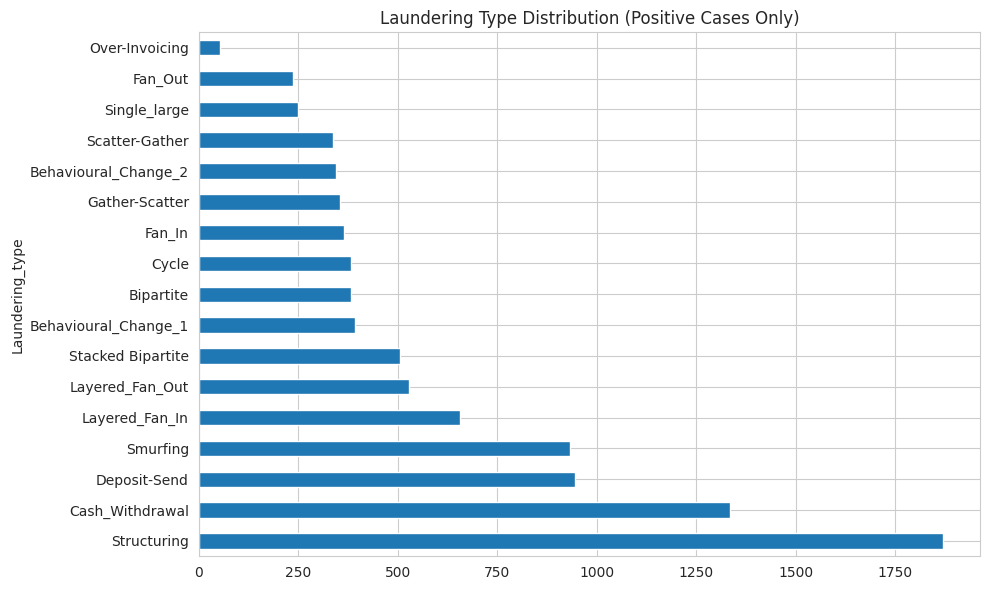

In [ ]:
if "Laundering_type" in df.columns:
    laundering_df = df[df["Is_laundering"] == 1]
    laundering_df["Laundering_type"].value_counts().plot(
        kind="barh", figsize=(10, 6), title="Laundering Type Distribution (Positive Cases Only)"
    )
    plt.tight_layout()
    plt.show()

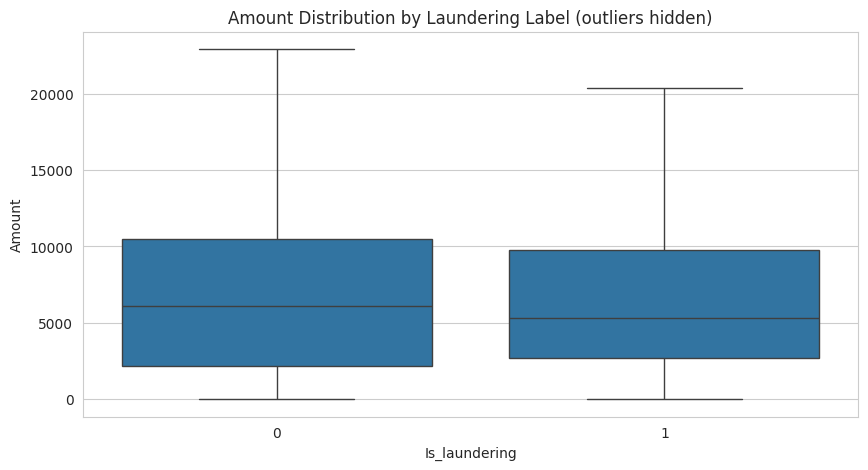

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(x="Is_laundering", y="Amount", data=df, ax=ax, showfliers=False)
ax.set_title("Amount Distribution by Laundering Label (outliers hidden)")
plt.show()

In [ ]:
from src.tools.eda_tool import run_eda
from src.tools.feature_engineering_tool import engineer_features
from src.tools.anomaly_detection_tool import detect_anomalies
from src.tools.risk_classification_tool import classify_risk
from src.tools.explanation_tool import explain_batch
from src.agent.orchestrator import run_agent

In [ ]:
sample_df = df.sample(20000, random_state=42)

result_1 = run_agent("Find structuring patterns in the last 30 days", sample_df)
result_1

{'query': 'Find structuring patterns in the last 30 days',
 'detected_intent': 'pattern_search',
 'detected_filters': {'amount_min': None,
  'amount_max': None,
  'country': None,
  'payment_type': None},
 'detected_pattern': 'structuring',
 'tools_invoked': ['feature_engineering',
  'anomaly_detection',
  'risk_classification',
  'explanation'],
 'flags': [{'Sender_account': 1600389541,
   'Receiver_account': 864370415,
   'Amount': 9096.26,
   'risk_level': 'High',
   'recommended_action': 'report',
   'explanation': 'This high-risk, cross-border transaction of 9,096.26 from the UK to Morocco was flagged due to its near-threshold amount and a significant rolling sum of 33,922.06 across multiple transfers.'},
  {'Sender_account': 59180432,
   'Receiver_account': 1707389298,
   'Amount': 9765.73,
   'risk_level': 'Medium',
   'recommended_action': 'flag for review',
   'explanation': 'This cross-border transaction was flagged because it triggered a near-threshold alert just below stand

In [ ]:
import time

time.sleep(60)
result_2 = run_agent("Which customers made 10+ transactions under $10,000?", sample_df)
result_2

{'query': 'Which customers made 10+ transactions under $10,000?',
 'detected_intent': 'aggregation_query',
 'detected_filters': {'amount_min': None,
  'amount_max': 10000,
  'country': None,
  'payment_type': None},
 'detected_pattern': None,
 'tools_invoked': ['aggregation'],
 'aggregation_result': {'aggregation_result': []}}

In [ ]:
import time

time.sleep(60)
result_3 = run_agent("Is customer ID 4521 suspicious?", sample_df)
result_3

{'query': 'Is customer ID 4521 suspicious?',
 'detected_intent': 'single_entity_lookup',
 'detected_filters': {'amount_min': None,
  'amount_max': None,
  'country': None,
  'payment_type': None},
 'detected_pattern': None,
 'tools_invoked': ['feature_engineering',
  'anomaly_detection',
  'risk_classification',
  'explanation'],
 'flags': [{'Sender_account': 4488572962,
   'Receiver_account': 737410870,
   'Amount': 9734.42,
   'risk_level': 'Medium',
   'recommended_action': 'flag for review',
   'explanation': 'This transaction was flagged due to a medium risk level driven by a near-threshold cross-border payment from the UK to the USA.'},
  {'Sender_account': 9334092695,
   'Receiver_account': 7010908534,
   'Amount': 9610.5,
   'risk_level': 'Medium',
   'recommended_action': 'flag for review',
   'explanation': 'This cross-border transaction of 9,610.5 from Austria to the UK was flagged as a medium risk due to its near-threshold amount.'},
  {'Sender_account': 1311372530,
   'Rec

In [ ]:
print(result_1["tools_invoked"])
print(result_2["tools_invoked"])
print(result_3["tools_invoked"])

['feature_engineering', 'anomaly_detection', 'risk_classification', 'explanation']
['aggregation']
['feature_engineering', 'anomaly_detection', 'risk_classification', 'explanation']
